In [1]:
from scoresbibm.src.tasks.multi_task import TwoMoonsAllConditionalTask, SLCPAllConditionalTask, NonlinearGaussianTreeAllConditionalTask, NonlinearMarcovChainAllConditionalTask
from scoresbibm.src.tasks.sbibm_tasks import TwoMoons, SBIBMTask
from scoresbibm.src.tasks.base_task import InferenceTask, Task, AllConditionalTask

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
task = TwoMoonsAllConditionalTask()
#task = SLCPAllConditionalTask()
#task = NonlinearMarcovChainAllConditionalTask()
# task = NonlinearGaussianTreeAllConditionalTask()

{}


In [3]:
dim = jax.tree_util.tree_reduce(lambda x, y: x + y, task.var_sizes)

In [4]:
base_mask_fn = task.get_base_mask_fn()
node_id = jnp.arange(dim)

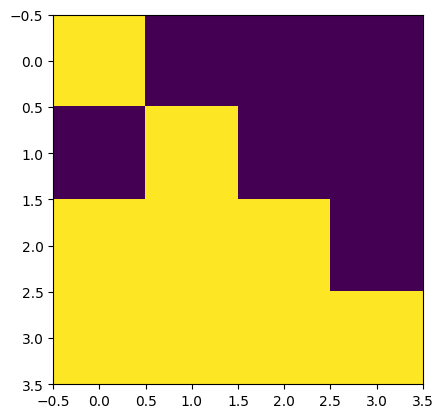

In [5]:
plt.imshow(base_mask_fn(node_id, None))

In [6]:
reference_sampler = task.get_reference_sampler()

In [7]:
# Two moons
theta, x = task.get_thetas_xs(1, rng=jax.random.PRNGKey(0))
theta_dim = theta.shape[-1]
x_dim = x.shape[-1]
print(x_dim, theta_dim)
samples = reference_sampler.sample(2000,x_o = x[0], condition_mask=jnp.array([0]*theta_dim + [1] * x_dim), rng=jax.random.PRNGKey(0))

2 2


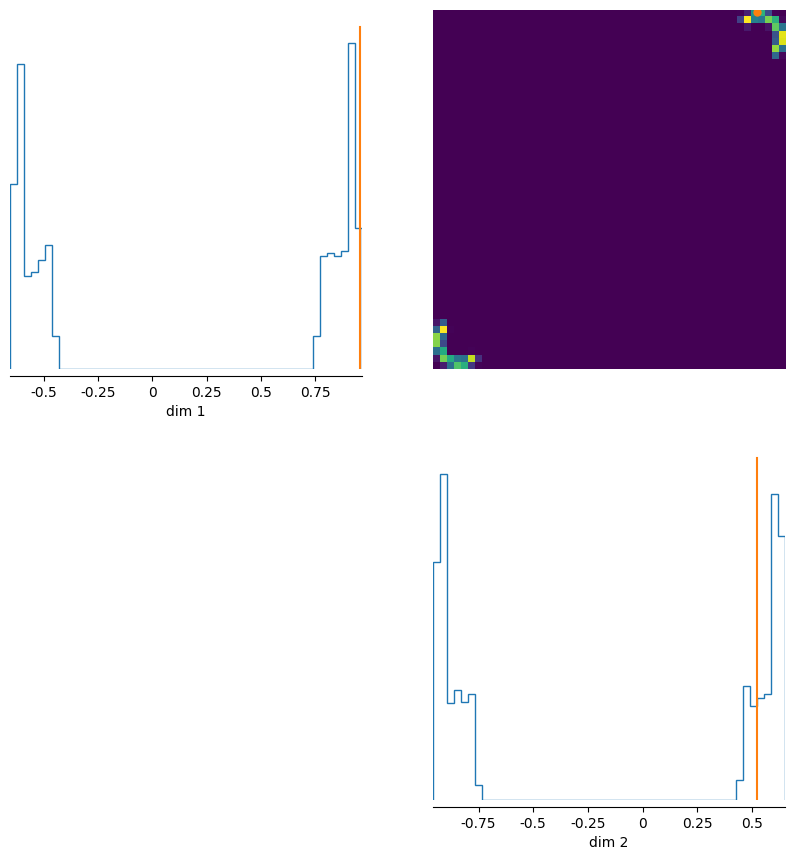

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sbi.analysis import pairplot
import numpy as np

_ = pairplot(np.array(samples), points=np.array(theta[0]))

[False  True  True  True] [ 0.109 -0.113 -0.296] [0.554]


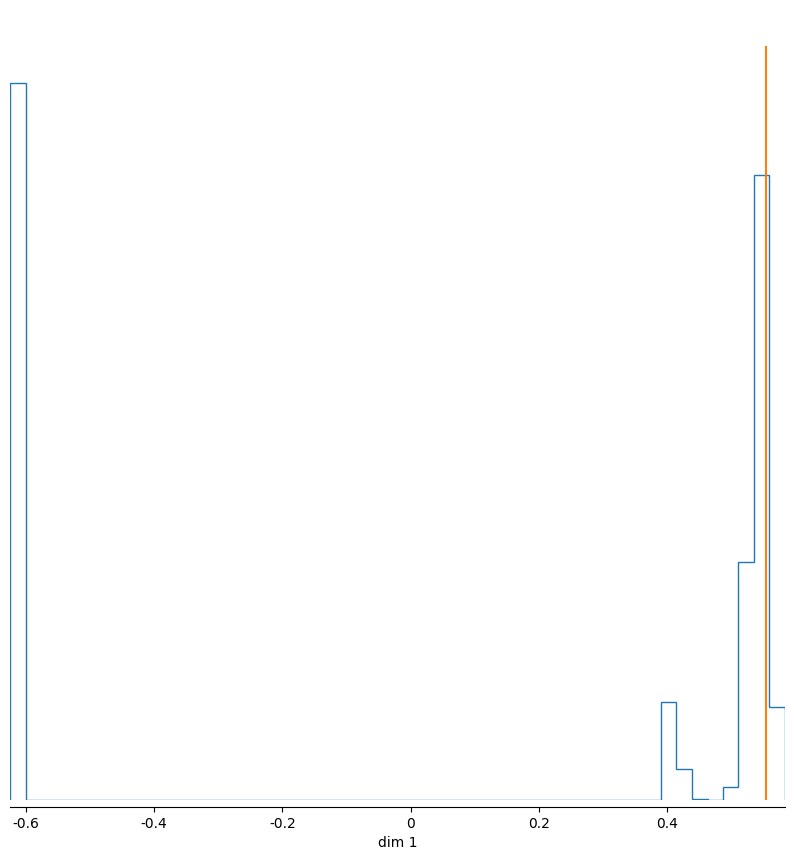

[ True False  True  True] [ 0.218  0.32  -0.309] [-0.178]


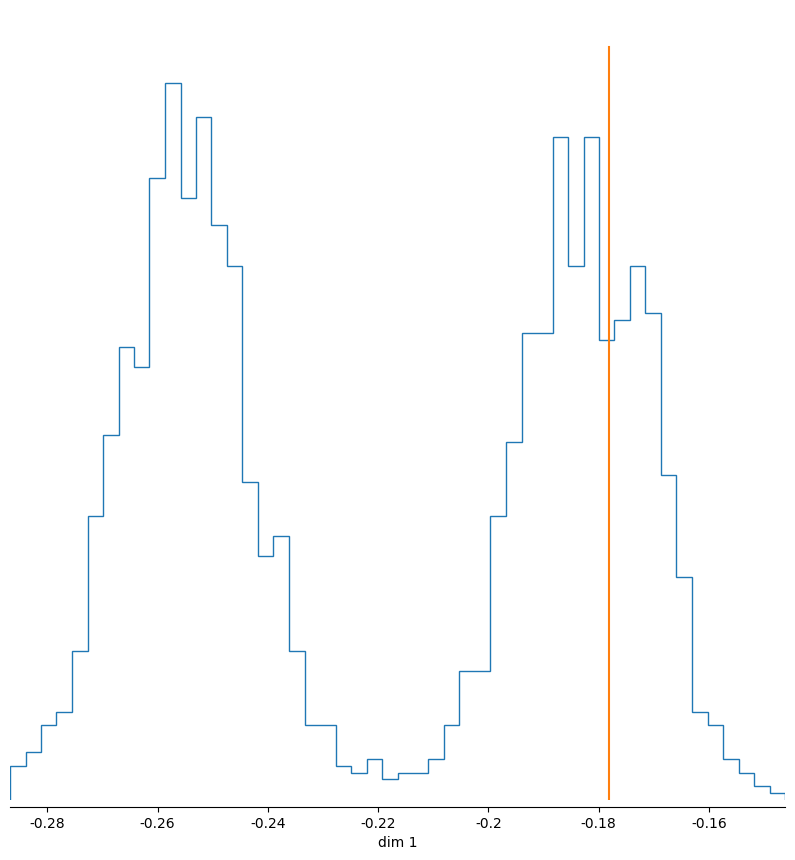

[False False False  True] [0.68] [-0.781  0.151 -0.11 ]


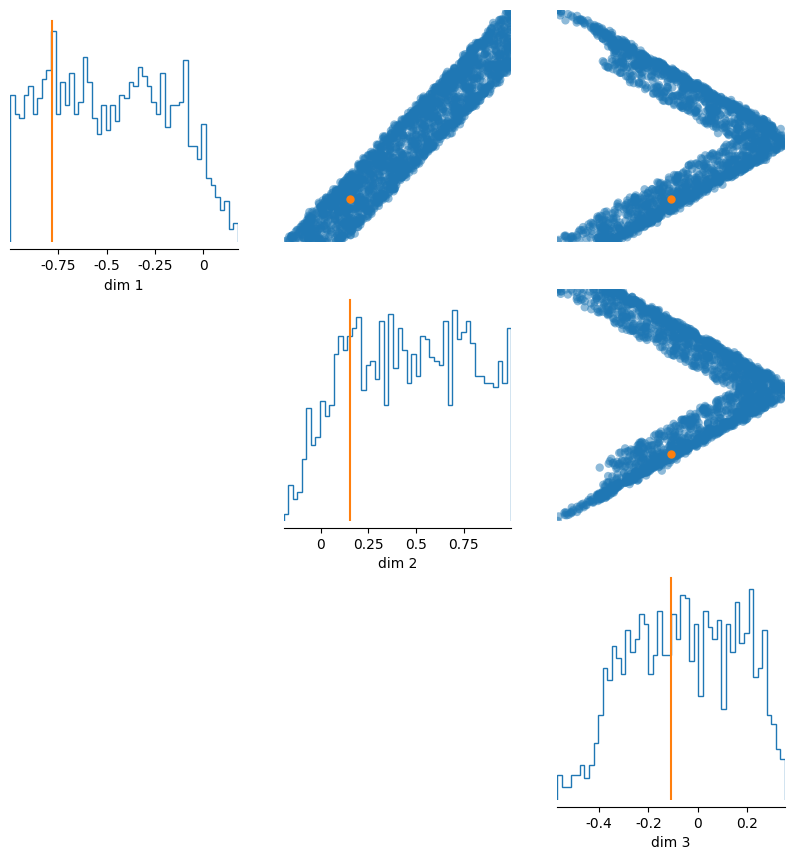

[ True False False False] [0.177] [ 0.547 -0.195  0.339]


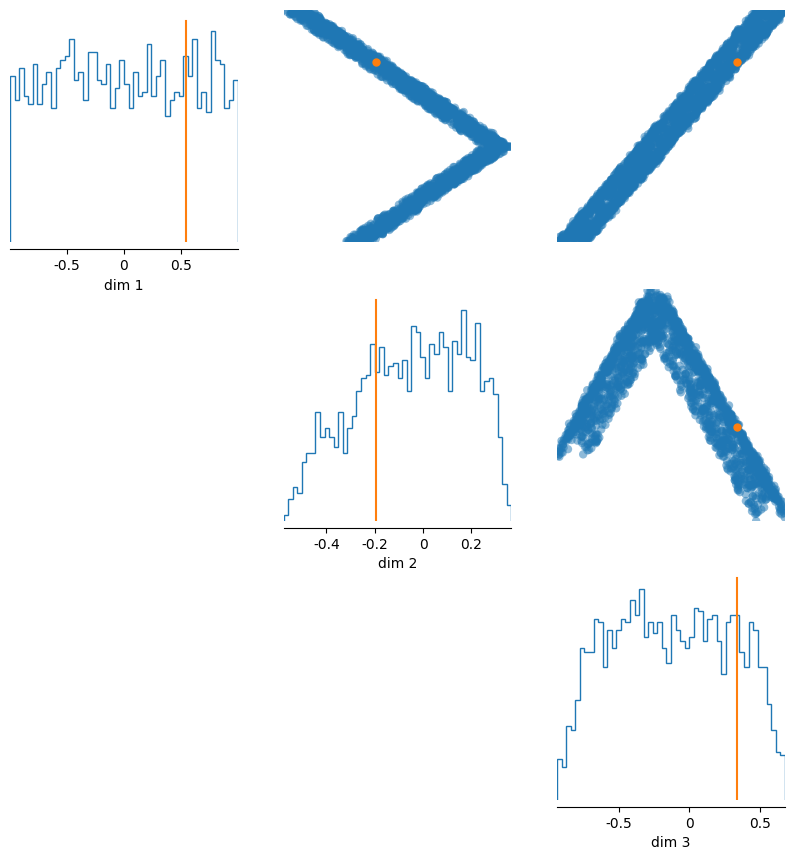

[ True False  True False] [ 0.32  -0.184] [-0.947 -0.999]


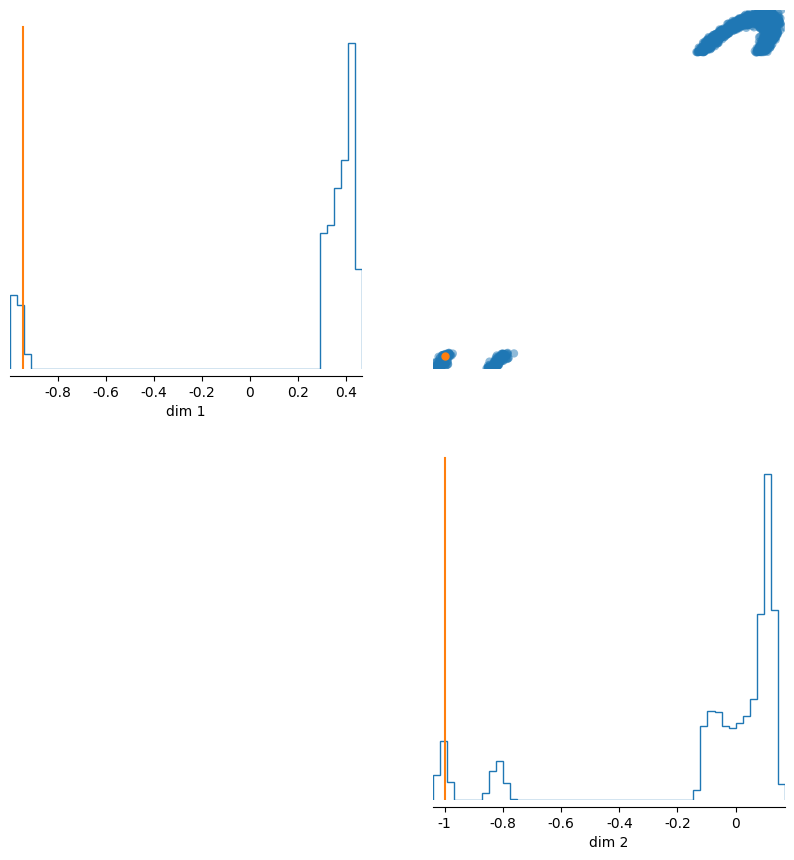

[False  True False False] [-0.339] [-0.315 -0.131 -0.066]


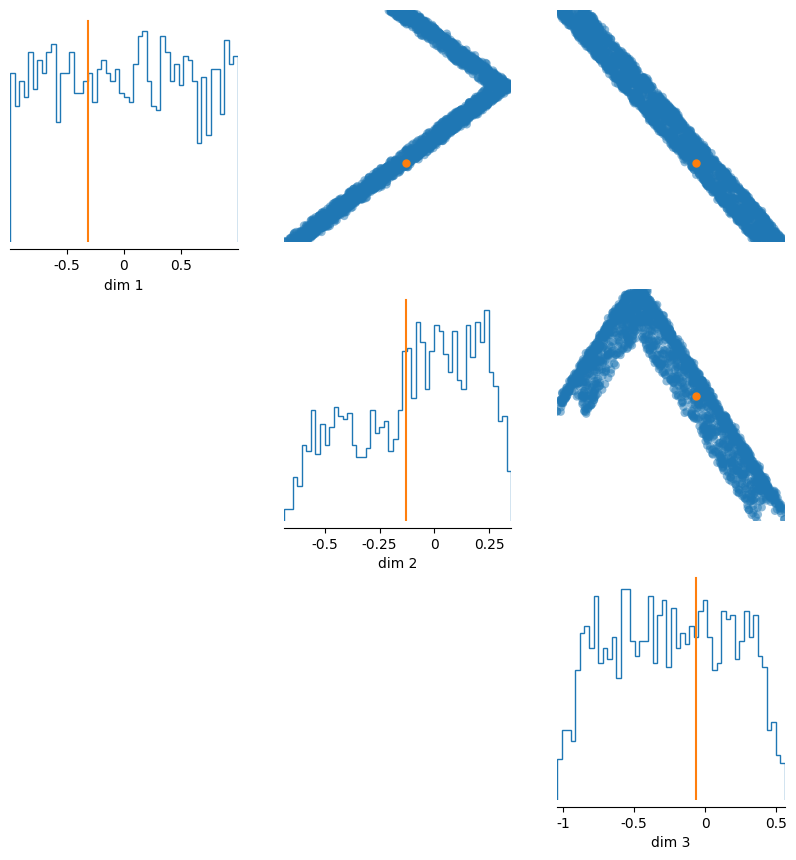

[ True  True  True False] [-0.279  0.495  0.166] [0.615]


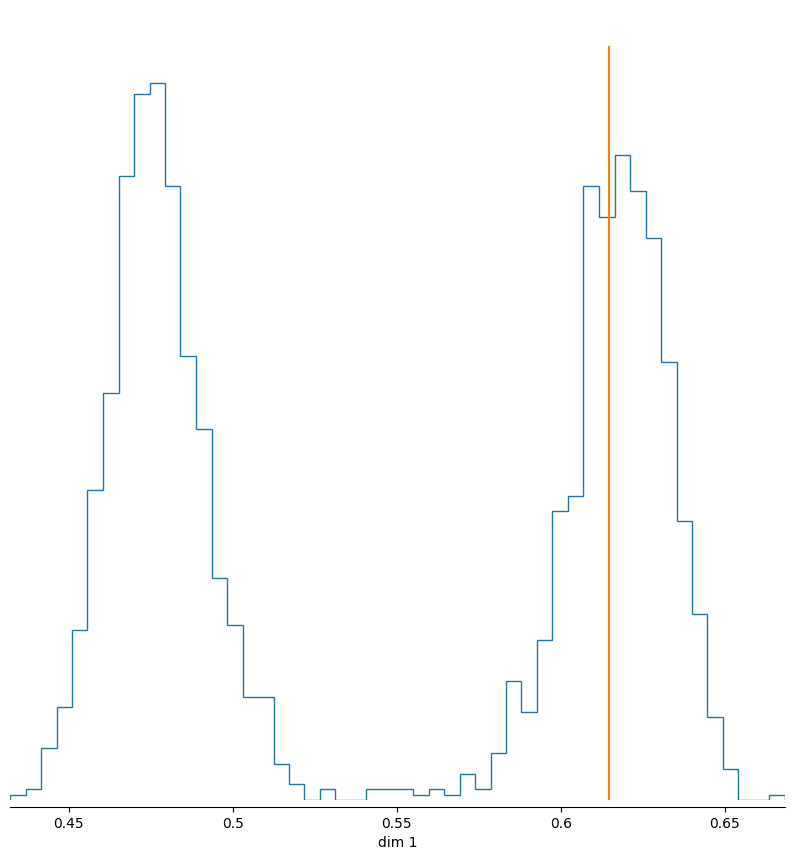

[False False False False] [] [ 0.345  0.869 -0.587  0.472]


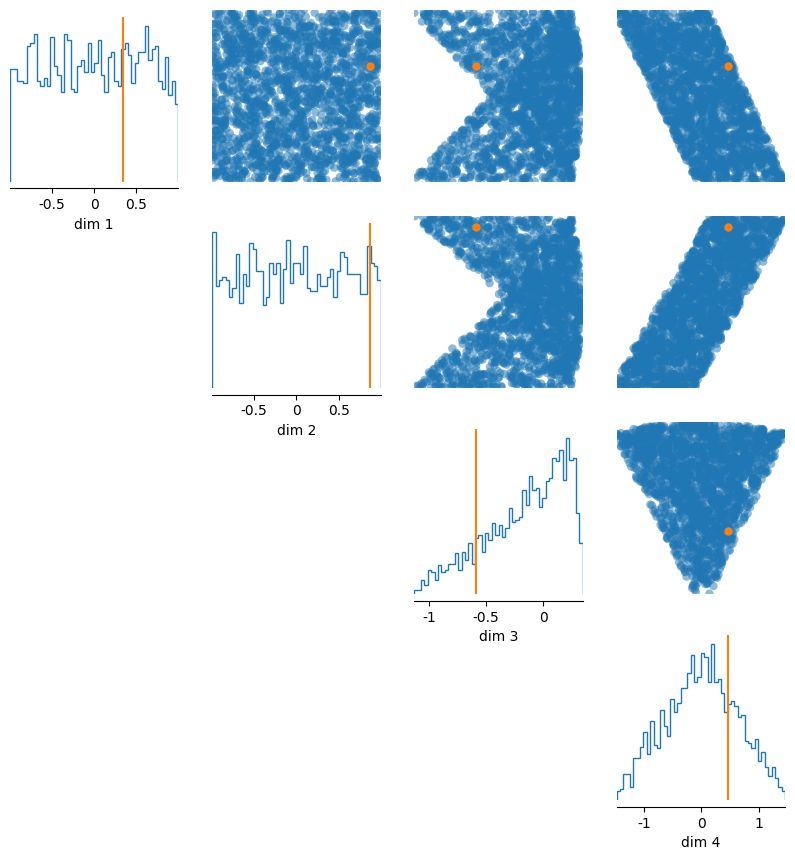

[ True  True False  True] [-0.742 -0.73  -0.072] [-0.755]


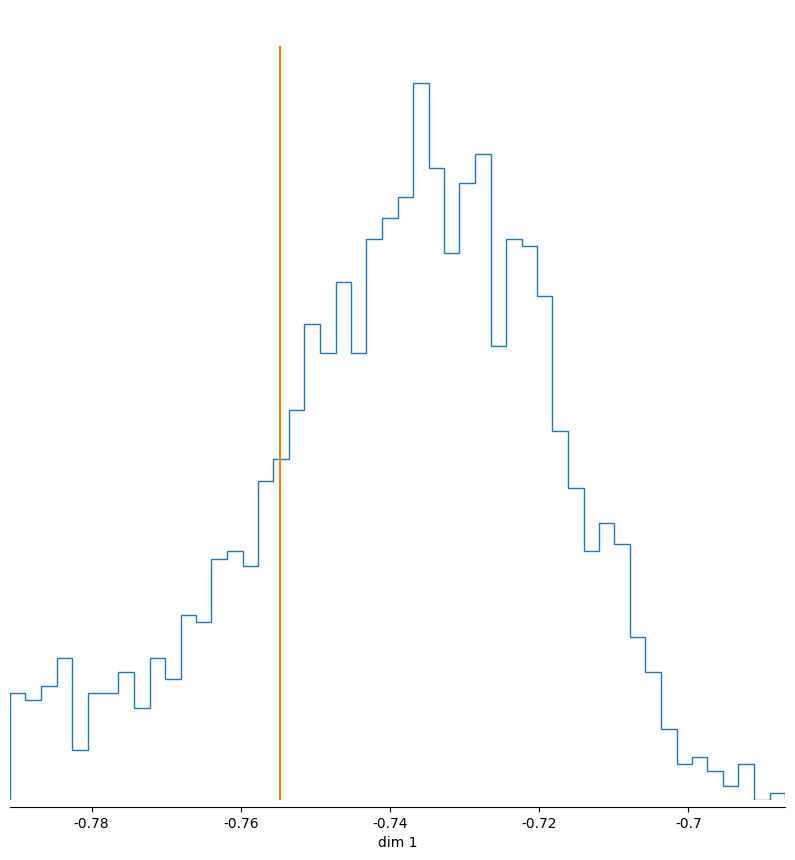

[False False False False] [] [-0.053  0.067  0.338  0.095]


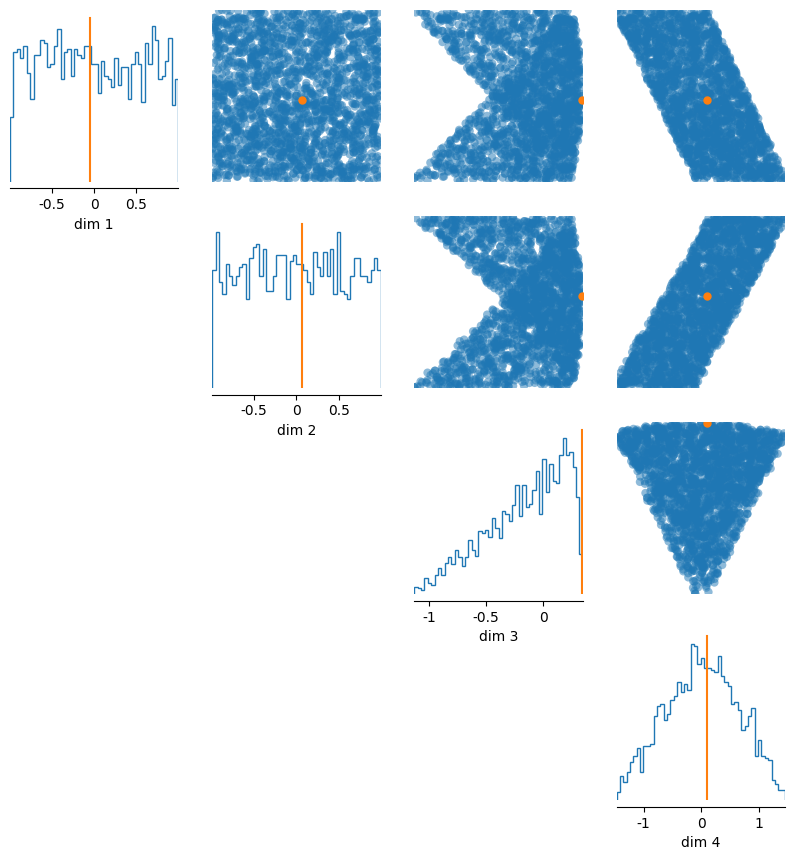

[False  True  True  True] [-0.559  0.055 -1.154] [0.942]


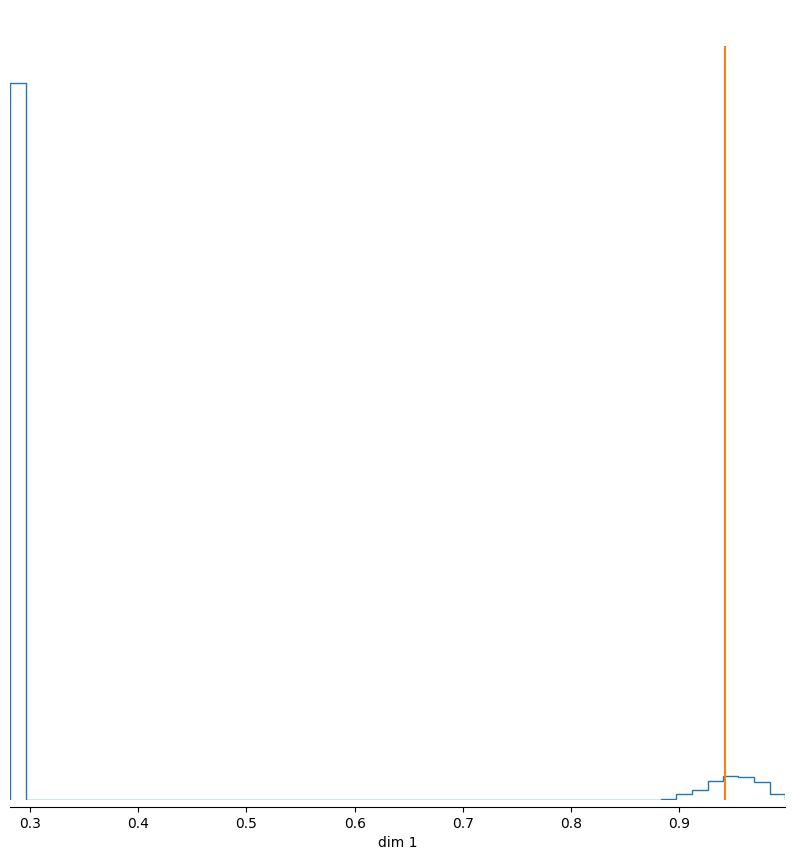

[False False  True  True] [-0.627  0.356] [0.462 0.821]


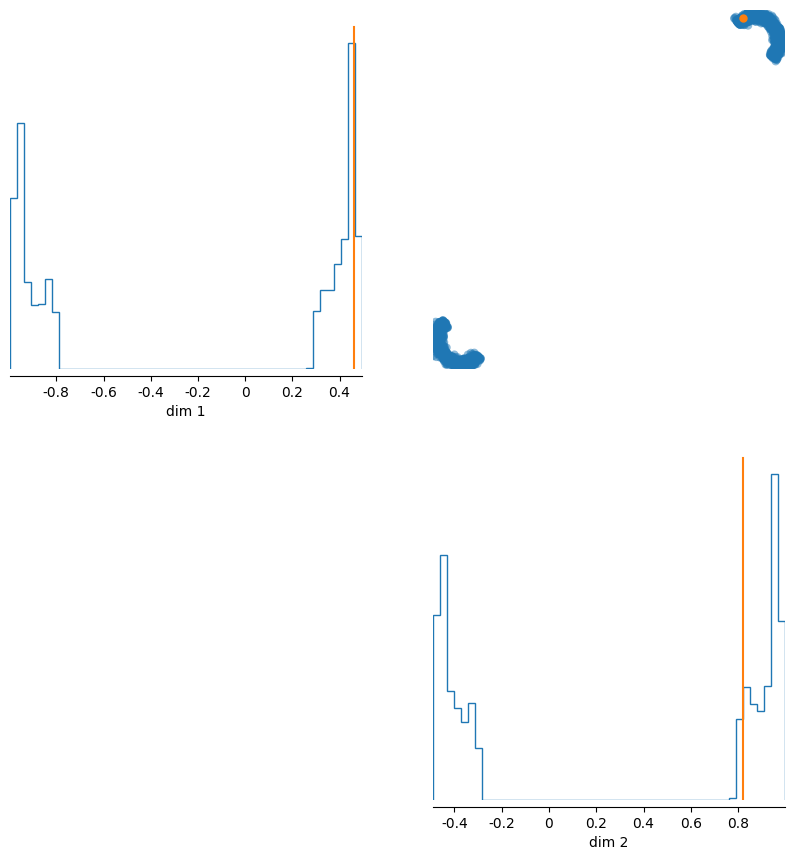

[ True  True  True False] [ 0.327  0.684 -0.416] [0.344]


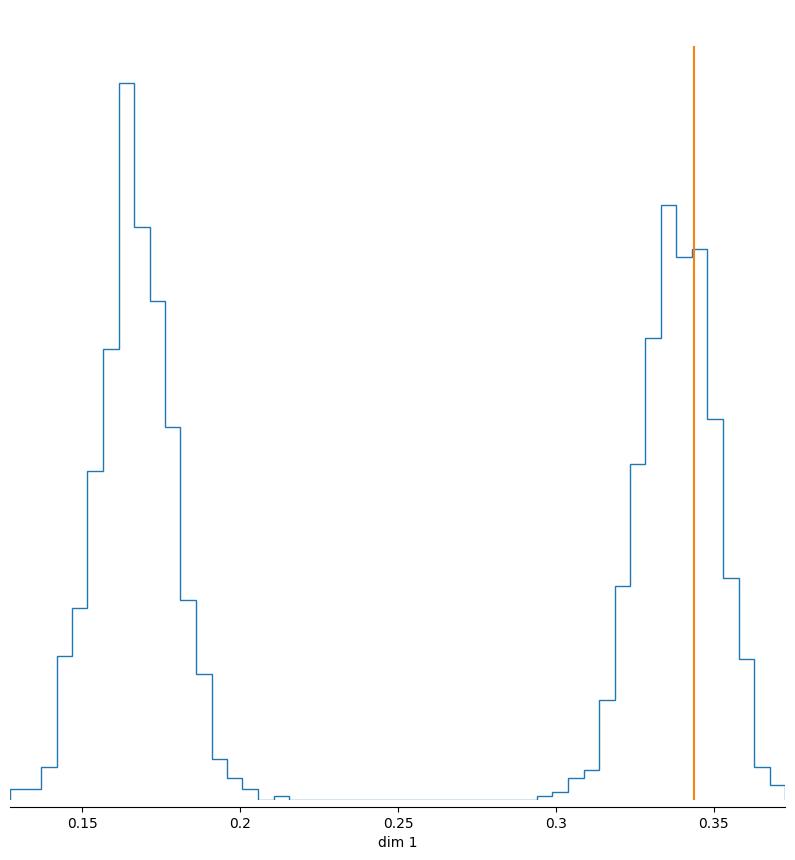

[False False False  True] [0.657] [-0.446  0.404  0.296]


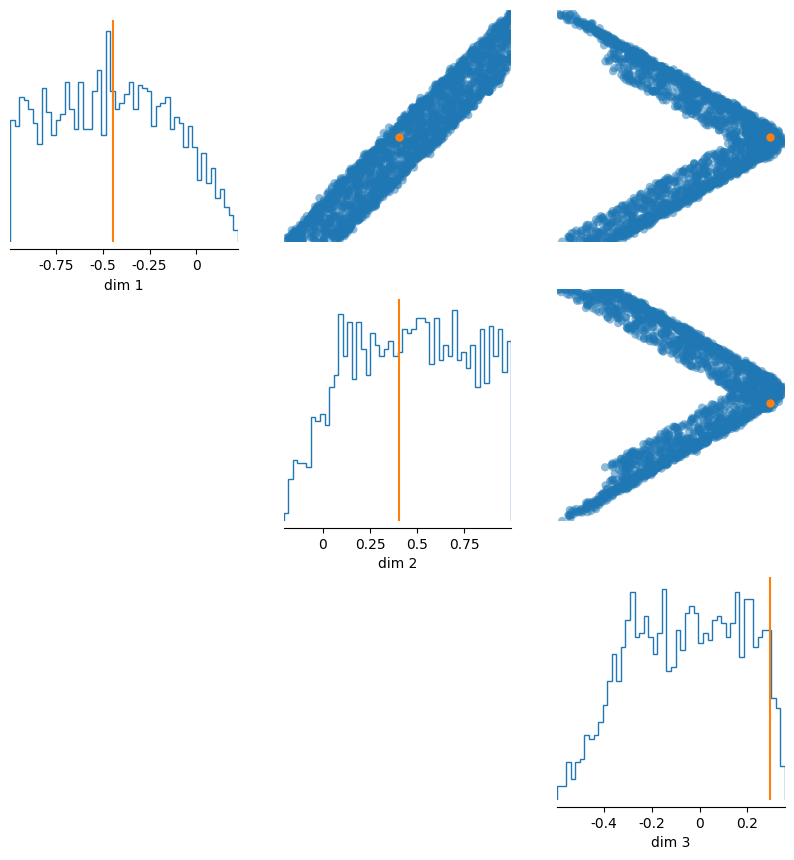

[False False False  True] [0.496] [-0.811 -0.092 -0.303]


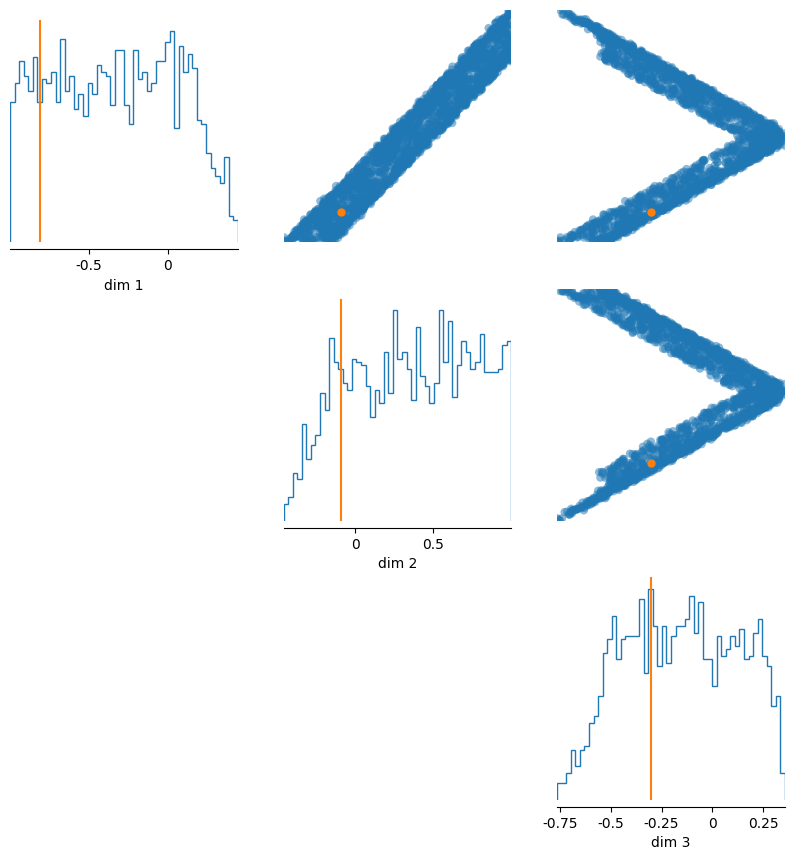

[ True False False  True] [ 0.838 -0.503] [ 0.102 -0.302]


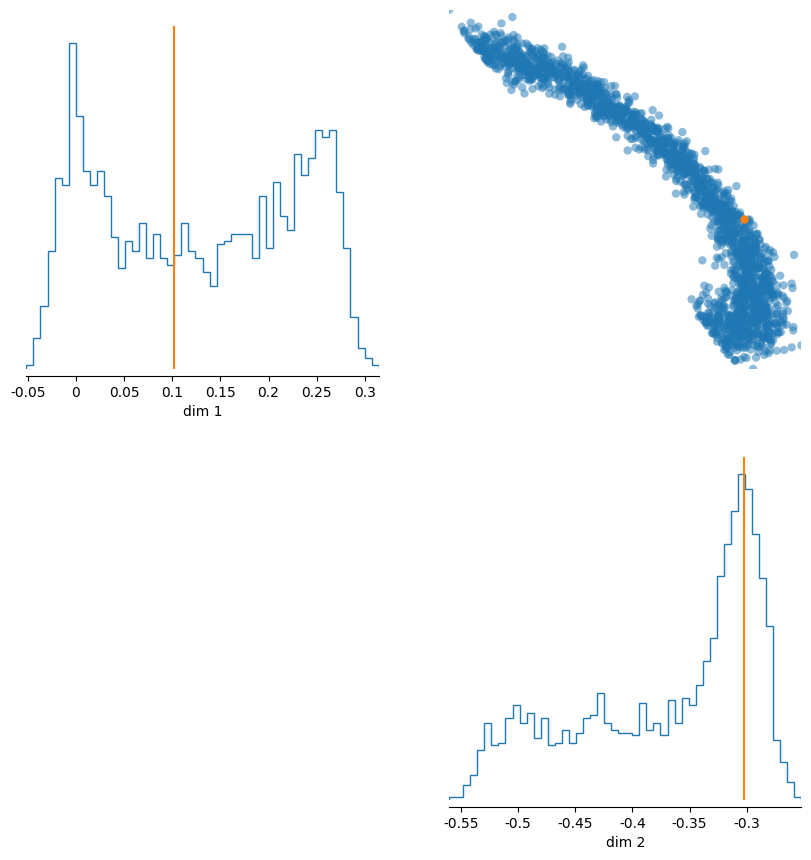

[False False False False] [] [-0.353 -0.767 -0.508 -0.382]


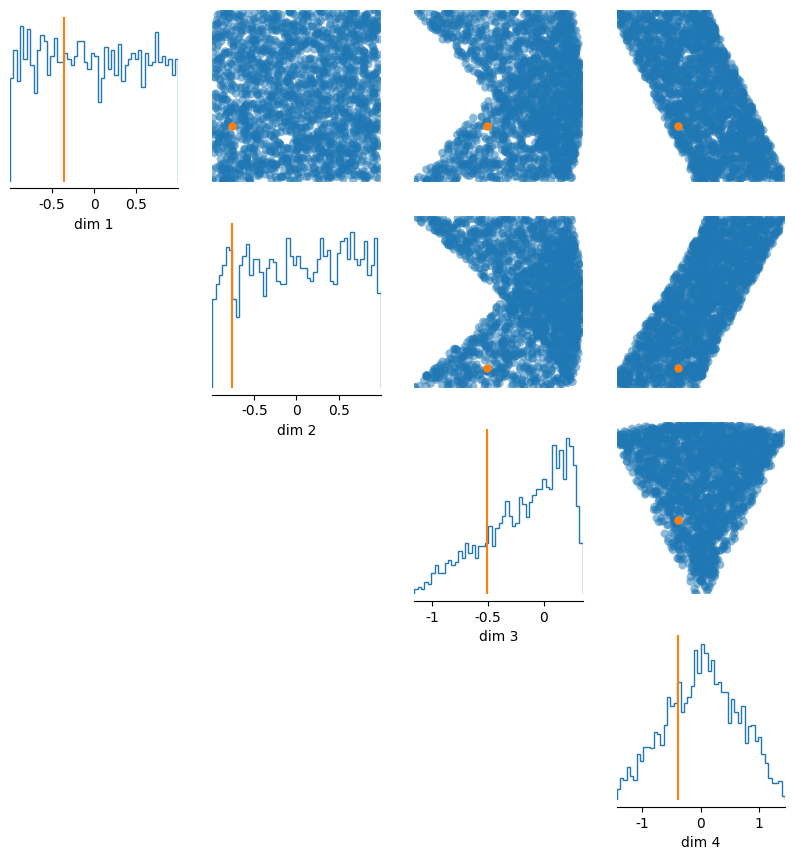

[ True  True  True False] [ 0.827 -0.613  0.164] [-1.111]


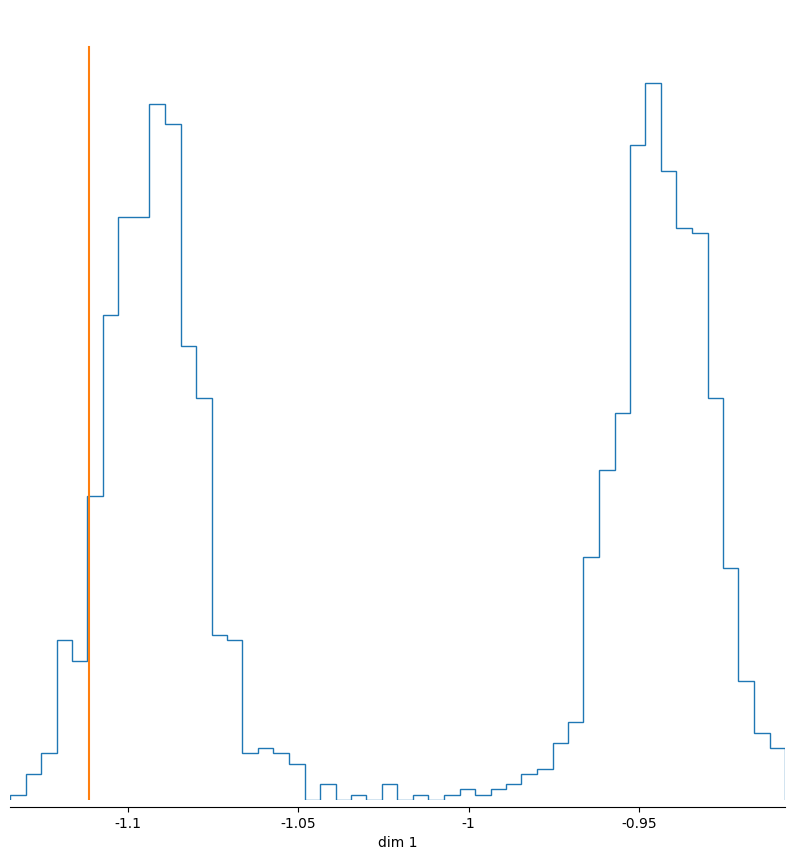

[ True False  True False] [ 0.983 -0.575] [ 0.335 -0.396]


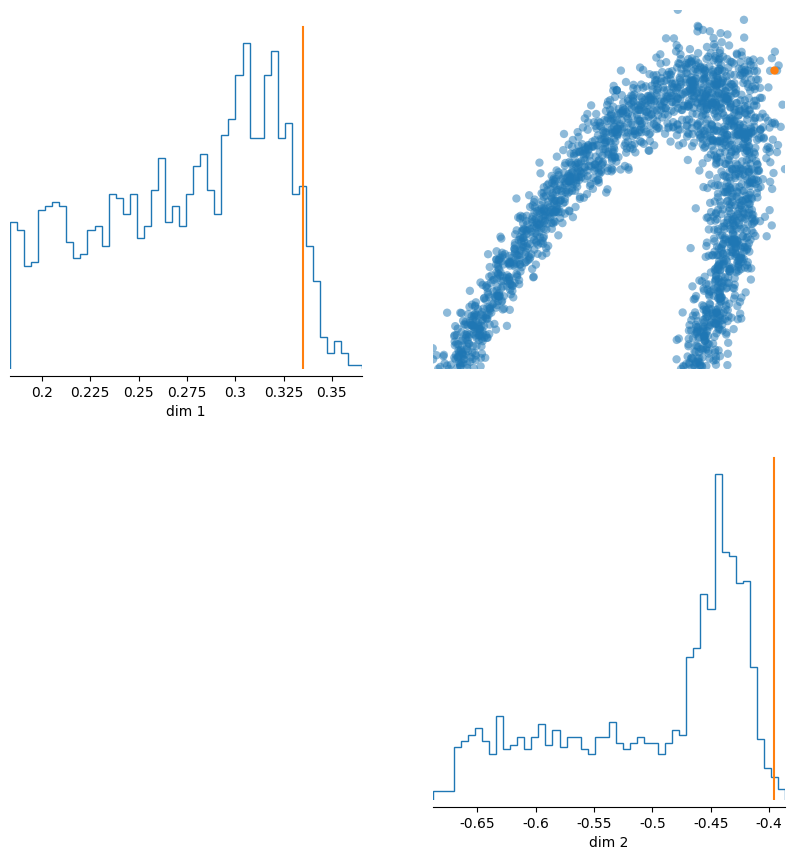

[False  True  True False] [ 0.969 -1.027] [0.845 0.202]


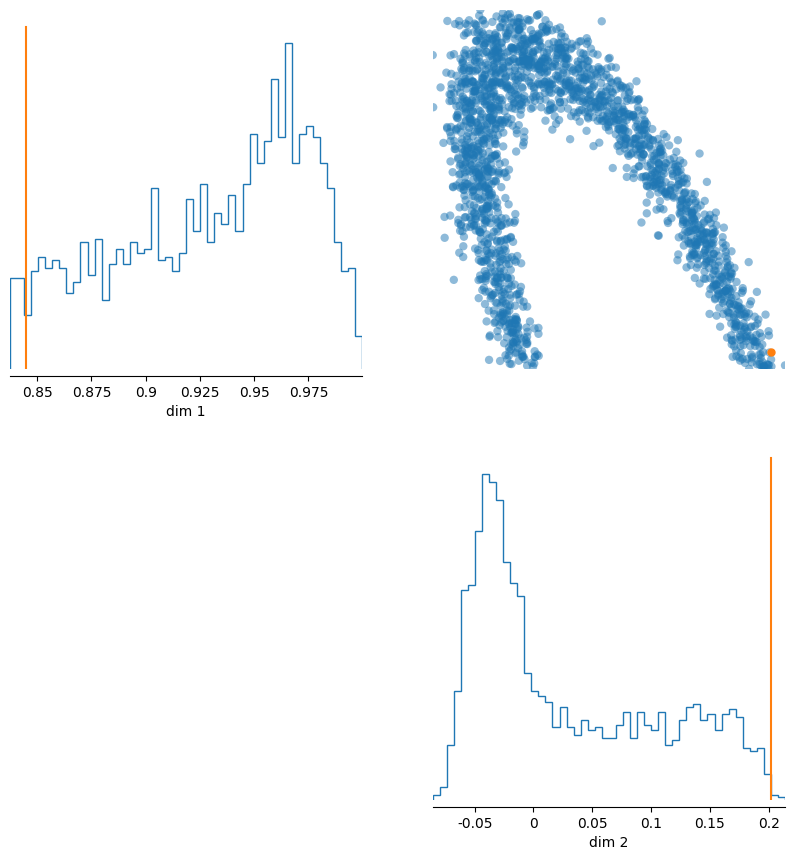

In [10]:
observation_stream = task.get_observation_generator()(jax.random.PRNGKey(0))
for i in range(20):
    # Two moons
    condition_mask, x_o, theta_o = next(observation_stream)
    print(condition_mask, x_o, theta_o)
    # Two moons
    samples = reference_sampler.sample(2000,x_o = x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(i))
    _ = pairplot(np.array(samples), points=np.array(theta_o), upper="scatter")
    plt.show()